<a href="https://colab.research.google.com/github/elisecolin/Tutorials_Notebooks/blob/main/Tree3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌲 Polarimetric Response of Dielectric Cylinders

This notebook explores the polarimetric behavior of thin dielectric cylinders, a fundamental building block commonly found in natural and urban environments (e.g., tree branches, poles, pipes).

---

## 🎯 Objectives

The goal of this notebook is to:

- Generate a synthetic "tree-like" structure composed of multiple oriented cylinders  
- Model their electromagnetic backscattering using a coherent formulation inspired by the Sarabandi model  
- Compare two key quantities:
  - **Geometric orientation angle (ψ_geo)**: obtained from the projection of the cylinder axis onto the radar polarization plane (H, V)  
  - **Electromagnetic orientation angle (ψ_EM)**: derived from the scattering matrix  

---

## 🧱 Scene Generation

The scene is built as a collection of finite cylindrical segments with varying orientations, mimicking a simplified vegetation structure. Each cylinder is defined by:

- its 3D orientation  
- its length and radius  
- its spatial position  

---

## ⚡ Electromagnetic Modeling

The backscattering response is computed using a coherent model of thin dielectric cylinders:

- the scattering matrix is evaluated for each segment  
- the Pauli vector representation is used to build the coherency matrix  
- the polarimetric orientation angle ψ_EM is extracted from this matrix  

---

## 📐 Geometric vs Electromagnetic Angles

Two interpretations of the cylinder orientation are compared:

- **ψ_geo**: purely geometric, based on projection in the transverse plane (H, V)  
- **ψ_EM**: physical, derived from electromagnetic interactions along the cylinder  

This comparison highlights the transition from a simple geometric model to a more complex electromagnetic behavior.

---

## 🔁 Parametric Studies

The notebook includes parametric analyses to explore:

- the effect of **frequency** on the polarimetric response  
- the effect of **dielectric permittivity**, modeled through varying moisture content  

---

## 🎥 Visualization

Results are visualized through:

- 2D maps of ψ_geo and ψ_EM over radar viewing angles  
- RGB representations  
- animated sequences (GIFs) showing the evolution of the response with frequency or moisture  

---

## 🧠 Key Insight

While the geometric model provides an intuitive understanding, the electromagnetic response reveals complex behaviors such as interference, resonance, and sensitivity to material properties.

---

 # RADAR Geometry definition

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# =======================
# RADAR GEOMETRY PARAMETERS
# =======================

R = 500e3
theta = np.deg2rad(40)   # incidence angle
phi =  np.deg2rad(10)               # azimuth angle

# -----------------------
# Incident wave vector (pointing downward)
# -----------------------
k = np.array([
    np.sin(theta) * np.cos(phi),
    np.sin(theta) * np.sin(phi),
    -np.cos(theta)
])
k /= np.linalg.norm(k)


# -----------------------
# Build a robust orthonormal polarization basis (H, V)
# -----------------------

def radar_basis(k):
    k = k / np.linalg.norm(k)

    n = np.array([0.0, 0.0, 1.0])

    H = np.cross(n, k)
    H /= np.linalg.norm(H)

    V = np.cross(k, H)
    V /= np.linalg.norm(V)

    return H, V

H,V=radar_basis(k)


# -----------------------
# Radar position (far-field approximation)
# -----------------------
def radar_position_from_k(k, R):
    k = k / np.linalg.norm(k)
    return -R * k


radar_pos = radar_position_from_k(k, R)



In [3]:
print('Radar Parameters ---------------------------')
print(f'Distance: {R} m')
print(f'Incidence angle: {np.rad2deg(theta)} deg')
print(f'Azimuth angle: {np.rad2deg(phi)} deg')
print(f'Incident wave vector: {k}')
print(f'Radar position: {radar_pos}')
print('--------------------------------------------')

Radar Parameters ---------------------------
Distance: 500000.0 m
Incidence angle: 40.0 deg
Azimuth angle: 10.0 deg
Incident wave vector: [ 0.63302222  0.1116189  -0.76604444]
Radar position: [-316511.11077974  -55809.44852447  383022.22155949]
--------------------------------------------


In [4]:
# =======================
# FREQUENCY AND PERMITIVITY
# =======================
epsr = 1 - 10j
freq = 5e9

# Tree generation

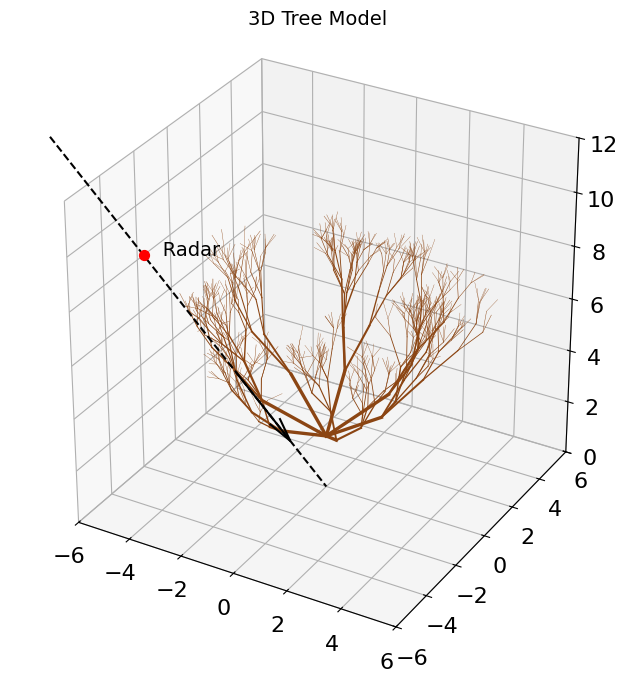

In [5]:
# =======================
# ROTATION MATRIX (Rodrigues)
# =======================
def rotation_matrix(axis, theta):
    axis = axis / np.linalg.norm(axis)
    K = np.array([
        [0, -axis[2], axis[1]],
        [axis[2], 0, -axis[0]],
        [-axis[1], axis[0], 0]
    ])
    return np.eye(3) + np.sin(theta)*K + (1-np.cos(theta))*(K@K)


# =======================
# TREE GROWTH MODEL
# =======================
def grow_tree(start, direction, length, radius, depth, segments):
    """
    Recursive tree growth using cylindrical segments.
    """

    if depth == 0 or radius < 0.01:
        return

    end = start + direction * length
    segments.append((start, end, direction, radius))

    # Number of branches depending on level
    if depth > 3:
        n_branches = np.random.choice([2,3], p=[0.6,0.4])
    else:
        n_branches = np.random.choice([2,3,4], p=[0.3,0.5,0.2])

    for _ in range(n_branches):

        # Branching angle distribution
        if depth >= 4:
            mean_angle = 35
            std_angle = 8
        elif depth >= 2:
            mean_angle = 50
            std_angle = 12
        else:
            mean_angle = 80
            std_angle = 15

        angle = np.deg2rad(np.random.normal(mean_angle, std_angle))
        angle = np.clip(angle, np.deg2rad(15), np.deg2rad(75))

        # Random rotation axis (slightly flattened vertically)
        axis = np.random.randn(3)
        axis[2] *= 0.9
        axis /= np.linalg.norm(axis)

        R = rotation_matrix(axis, angle)
        new_dir = R @ direction

        # Upward growth bias
        up = np.array([0,0,1])
        new_dir = 0.7*new_dir + 0.3*up
        new_dir = 0.95*new_dir + 0.05*up
        new_dir /= np.linalg.norm(new_dir)

        grow_tree(
            end,
            new_dir,
            length * np.random.uniform(0.65, 0.8),
            radius * np.random.uniform(0.55, 0.7),
            depth - 1,
            segments
        )


# =======================
# INITIAL STRUCTURE (gobelet)
# =======================
def init_gobelet():
    dirs = []
    for angle in np.linspace(0, 2*np.pi, 7, endpoint=False):
        d = np.array([
            np.cos(angle),
            np.sin(angle),
            np.random.uniform(0.5, 0.7)
        ])
        dirs.append(d / np.linalg.norm(d))
    return dirs


# =======================
# TREE GENERATION
# =======================
np.random.seed(10)

segments = []
root = np.array([0,0,0])

for d in init_gobelet():
    grow_tree(root, d, 2.5, 0.12, 7, segments)


# =======================
# APPLY VERTICAL SHIFT (+2 m)
# =======================
shift = np.array([0, 0, 2.0])

segments = [
    (start + shift, end + shift, direction, radius)
    for start, end, direction, radius in segments
]


# =======================
# 3D VISUALIZATION
# =======================
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Plot tree segments
for start, end, direction, radius in segments:
    ax.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        [start[2], end[2]],
        linewidth=radius*20,
        color='saddlebrown'
    )

# -----------------------
# Radar line-of-sight vector
# -----------------------
arrow_origin = -5 * k     # placed along LOS
arrow_vec = 3 * k         # pointing toward scene

ax.quiver(*arrow_origin, *arrow_vec, color='black', label='k (LOS)')
ax.tick_params(labelsize=16)
# Optional: radar position marker
# Line-of-sight (dashed line)
# -----------------------
los_start = -15 * k
los_end = np.array([0, 0, 0])

ax.plot(
    [los_start[0], los_end[0]],
    [los_start[1], los_end[1]],
    [los_start[2], los_end[2]],
    linestyle='--',
    color='black',
    linewidth=1.5,
    label='LOS'
)
ax.scatter(*(-10*k), color='red', s=50)
ax.text(*(-10*k), "   Radar",fontsize=14)

# -----------------------
# Display settings
# -----------------------
ax.set_box_aspect([1,1,1])
ax.set_xlim(-6,6)
ax.set_ylim(-6,6)
ax.set_zlim(0,12)

ax.set_title("3D Tree Model",fontsize=14)

plt.show()

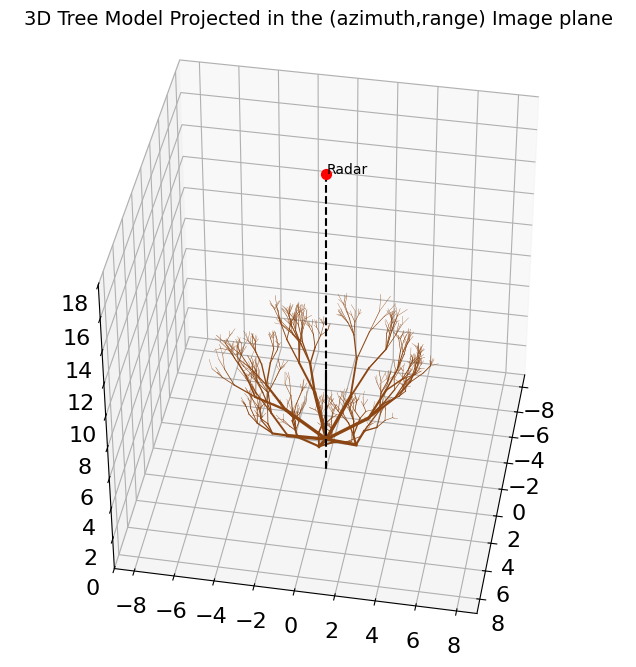

In [6]:
# =======================
# CAMERA aligned with V
# =======================
vx, vy, vz = V

azim = np.degrees(np.arctan2(vy, vx))
elev = np.degrees(np.arcsin(vz))




# =======================
# 3D VISUALIZATION
# =======================
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# Plot tree segments
for start, end, direction, radius in segments:
    ax.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        [start[2], end[2]],
        linewidth=radius*20,
        color='saddlebrown'
    )

# -----------------------
# Radar line-of-sight vector
# -----------------------
arrow_origin = -5 * k     # placed along LOS
arrow_vec = 3 * k         # pointing toward scene

ax.quiver(*arrow_origin, *arrow_vec, color='black', label='k (LOS)')

# Optional: radar position marker
# Line-of-sight (dashed line)
# -----------------------
los_start = -15 * k
los_end = np.array([0, 0, 0])

ax.plot(
    [los_start[0], los_end[0]],
    [los_start[1], los_end[1]],
    [los_start[2], los_end[2]],
    linestyle='--',
    color='black',
    linewidth=1.5,
    label='LOS'
)
ax.scatter(*(-15*k), color='red', s=50)
ax.text(*(-15*k), "Radar")

# -----------------------
# Display settings
# -----------------------
ax.set_box_aspect([1,1,1])
ax.set_xlim(-9,9)
ax.set_ylim(-9,9)
ax.set_zlim(0,18)
ax.view_init(elev=elev, azim=azim)
ax.set_title("3D Tree Model Projected in the (azimuth,range) Image plane",fontsize=14)
ax.tick_params(labelsize=16)

plt.show()

In [7]:
print('Radar Parameters ---------------------------')
print(f'Distance: {R} m')
print(f'Incidence angle: {np.rad2deg(theta)} deg')
print(f'Azimuth angle: {np.rad2deg(phi)} deg')
print(f'Incident wave vector: {k}')
print(f'Radar position: {radar_pos}')
print('--------------------------------------------')

Radar Parameters ---------------------------
Distance: 500000.0 m
Incidence angle: 40.0 deg
Azimuth angle: 10.0 deg
Incident wave vector: [ 0.63302222  0.1116189  -0.76604444]
Radar position: [-316511.11077974  -55809.44852447  383022.22155949]
--------------------------------------------


# CYLINDER Modelling

In [8]:
# =======================
# Repère local cylindre
# =======================
def cylinder_frame(direction):
    z = direction / np.linalg.norm(direction)

    # vecteur orthogonal arbitraire
    tmp = np.array([1,0,0])
    if abs(np.dot(tmp, z)) > 0.999:
        tmp = np.array([0,1,0])

    x = np.cross(tmp, z)
    x /= np.linalg.norm(x)

    y = np.cross(z, x)

    return np.vstack([x, y, z])

In [9]:
import numpy as np
from scipy.special import jv, hankel1


# =======================
# BESSEL / HANKEL FAMILY
# =======================
def bessel_family(m, z):
    """
    Compute Bessel and Hankel functions (and their derivatives)
    for a set of cylindrical modes.

    Parameters
    ----------
    m : array_like (int)
        Mode indices (can be negative, zero, positive).
    z : complex or float
        Argument of the Bessel/Hankel functions.

    Returns
    -------
    jm : ndarray (complex)
        Bessel function of the first kind J_m(z)
    h1m : ndarray (complex)
        Hankel function of the first kind H_m^(1)(z)
    jpm : ndarray (complex)
        Derivative of J_m(z) with respect to z
    h1pm : ndarray (complex)
        Derivative of H_m^(1)(z) with respect to z
    """

    jm = jv(m, z)
    h1m = hankel1(m, z)

    # Derivatives using recurrence relations
    jpm = 0.5 * (jv(m-1, z) - jv(m+1, z))
    h1pm = 0.5 * (hankel1(m-1, z) - hankel1(m+1, z))

    return jm, h1m, jpm, h1pm


# =======================
# LOCAL CYLINDER SCATTERING
# =======================
def FlocalSarab(n, repereip, reperesp, k0, epsr, cylindre, xp, yp, zp):
    """
    Compute the local scattering matrix of a finite dielectric cylinder
    using a modal expansion (Sarabandi-type formulation).

    This function returns the 2x2 complex scattering matrix expressed
    in the local polarization basis of the cylinder.

    Parameters
    ----------
    n : int
        Maximum mode order (expansion from -n to +n)

    repereip : ndarray (3x3)
        Incident wave reference frame (H, V, k_i)
        Rows correspond to basis vectors expressed in global coordinates

    reperesp : ndarray (3x3)
        Scattered wave reference frame (H, V, k_s)

    k0 : float
        Free-space wavenumber (2π / λ)

    epsr : complex
        Relative permittivity of the cylinder material

    cylindre : ndarray (2,)
        Cylinder geometry:
        cylindre[0] = radius (a)
        cylindre[1] = half-length (h/2)

    xp, yp, zp : ndarray (3,)
        Local orthonormal basis of the cylinder:
        zp = cylinder axis
        xp, yp = transverse directions

    Returns
    -------
    n : int
        Maximum mode index used (same as input)

    Fp : ndarray (2x2 complex)
        Local scattering (Sinclair) matrix in cylinder basis
        (H_local, V_local)
    """

    PI = np.pi
    II = 1j

    # Cylinder geometry
    a = cylindre[0]
    h = cylindre[1] * 2.0
    epsrb = np.conj(epsr)

    # ----------------------------
    # LOCAL GEOMETRY (INCIDENCE ANGLE)
    # ----------------------------
    xpp = xp
    ypp = yp
    zpp = zp

    # Projection of incident direction onto cylinder frame
    sinbe = -np.dot(xpp, repereip[2])
    cosbe = np.dot(zpp, repereip[2])

    sinbe = np.clip(sinbe, -1, 1)
    cosbe = np.clip(cosbe, -1, 1)

    # Avoid numerical singularities
    if abs(sinbe) < 1e-6:
        sinbe = 1e-6

    # ----------------------------
    # DIMENSIONLESS PARAMETERS
    # ----------------------------
    x0 = k0 * a * sinbe
    x1 = k0 * a * np.sqrt(epsrb - cosbe**2 + 0j)
    y0 = k0 * a

    # ----------------------------
    # MODE INDICES
    # ----------------------------
    m = np.arange(-n, n+1)

    # Bessel/Hankel evaluations
    jm0, h1m0, jpm0, h1pm0 = bessel_family(m, x0)
    jm1, h1m1, jpm1, h1pm1 = bessel_family(m, x1)
    jmy, h1my, jpmy, h1pmy = bessel_family(m, y0)

    # ----------------------------
    # ELECTROMAGNETIC COEFFICIENTS
    # ----------------------------
    qm = m * k0 * a * cosbe * (1/(x1**2 + 1e-12) - 1/(x0**2 + 1e-12))

    Vm = k0*a*((epsrb/x1)*jm0*jpm1 - (1/x0)*jpm0*jm1)
    Pm = k0*a*((1/x1)*h1m0*jpm1 - (1/x0)*h1pm0*jm1)
    Nm = k0*a*((epsrb/x1)*h1m0*jpm1 - (1/x0)*h1pm0*jm1)
    Mm = k0*a*((1/x1)*jm0*jpm1 - (1/x0)*jpm0*jm1)

    denom = Pm*Nm - (qm*h1m0*jm1)**2 + 1e-12

    # TM / TE modal coefficients
    CmTM = -(Vm*Pm - qm**2 * jm0*h1m0*jm1**2) / denom
    CmTE = -(Mm*Nm - qm**2 * jm0*h1m0*jm1**2) / denom
    Cmb  = (II*2/(PI*x0*sinbe + 1e-12)) * (qm*jm1**2) / denom

    # ----------------------------
    # INCIDENT POLARIZATION
    # ----------------------------
    Ei = np.array([1.0, 0.0])   # Horizontal polarization
    Hi = np.array([0.0, -1.0])  # Associated magnetic field

    # ----------------------------
    # MODAL FIELD COEFFICIENTS
    # ----------------------------
    Am = CmTM[:, None]*Ei + II*Cmb[:, None]*Hi
    Bm = CmTE[:, None]*Hi - II*Cmb[:, None]*Ei

    # ----------------------------
    # AZIMUTHAL PHASE (simplified)
    # ----------------------------
    phi = 0.0
    phase = np.exp(1j * m * phi)

    al1 = 2*PI*jmy * phase
    al2 = 2*PI*II*jpmy * phase
    al3 = -2*PI*jmy*m * phase

    # ----------------------------
    # SIGN CORRECTION (-1)^m
    # ----------------------------
    sign = np.where(m % 2 == 0, 1.0, -1.0)

    # ----------------------------
    # MODAL FIELD COMPONENTS
    # ----------------------------
    ezm = sign[:, None] * (jm0[:, None]*Ei + Am*h1m0[:, None])
    hzm = sign[:, None] * (jm0[:, None]*Hi + Bm*h1m0[:, None])

    epm = sign[:, None]/(II*(sinbe**2)*k0 + 1e-12) * (
        k0*sinbe*(jpm0[:, None]*Hi + Bm*h1pm0[:, None])
        - II*m[:, None]*cosbe/a*(jm0[:, None]*Ei + Am*h1m0[:, None])
    )

    hpm = sign[:, None]/(II*(sinbe**2)*k0 + 1e-12) * (
        -k0*sinbe*(jpm0[:, None]*Ei + Am*h1pm0[:, None])
        - II*m[:, None]*cosbe/a*(jm0[:, None]*Hi + Bm*h1m0[:, None])
    )

    # ----------------------------
    # FINAL SCATTERING MATRIX
    # ----------------------------
    Fp = np.zeros((2, 2), dtype=complex)

    for pol in range(2):
        Fp[0, pol] = np.sum(hpm[:, pol]*al1 - hzm[:, pol]*al3 - ezm[:, pol]*al2)
        Fp[1, pol] = np.sum(hzm[:, pol]*al2 + epm[:, pol]*al1 - ezm[:, pol]*al3)

    return n, np.conj(Fp)

In [10]:
def cylinder_scattering_local(n, k0, epsr, cyl, xp, yp, zp, H, V, k):
    """
    Compute the local scattering matrix of a cylinder using FlocalSarab,
    given the radar illumination geometry.

    This function builds the incident and scattered reference frames
    required by the electromagnetic solver, then calls FlocalSarab
    to obtain the scattering matrix in the cylinder local basis.

    Parameters
    ----------
    n : int
        Maximum mode order for the cylindrical modal expansion.

    k0 : float
        Free-space wavenumber (2π / λ).

    epsr : complex
        Relative permittivity of the cylinder material.

    cyl : ndarray (2,)
        Cylinder geometry:
            cyl[0] = radius (meters)
            cyl[1] = half-length (meters)

    xp, yp, zp : ndarray (3,)
        Local orthonormal basis of the cylinder:
            zp : cylinder axis
            xp, yp : transverse directions (scattering plane)

    H, V : ndarray (3,)
        Radar polarization basis vectors:
            H : horizontal polarization
            V : vertical polarization
        Both orthogonal to propagation direction k.

    k : ndarray (3,)
        Incident wave direction (unit vector) from radar to target.

    Returns
    -------
    F_local : ndarray (2x2 complex)
        Scattering (Sinclair) matrix expressed in the local cylinder basis
        (xp, yp).

    Notes
    -----
    The function constructs two reference frames:

    - Incident frame (repereip):
        [H, V, k]

    - Scattered frame (reperesp):
        [H, V, -k]

    corresponding to a monostatic radar configuration.

    Physical interpretation:
        - The radar defines the illumination geometry (H, V, k)
        - The cylinder defines its own local frame (xp, yp, zp)
        - FlocalSarab computes how the cylinder scatters under this illumination

    Important:
        The output matrix is NOT yet expressed in the radar basis.
        A projection step is required (see project_local_to_radar).
    """

    # -----------------------
    # Build incident reference frame
    # -----------------------
    repereip = np.vstack([H, V, k])

    # -----------------------
    # Build scattered reference frame (monostatic case)
    # -----------------------
    reperesp = np.vstack([H, V, -k])

    # -----------------------
    # Call electromagnetic solver (cylinder response)
    # -----------------------
    _, F_local = FlocalSarab(
        n=n,
        repereip=repereip,
        reperesp=reperesp,
        k0=k0,
        epsr=epsr,
        cylindre=cyl,
        xp=xp,
        yp=yp,
        zp=zp
    )

    return F_local

In [11]:
def project_local_to_radar(F_local, xp, yp, H, V):
    """
    Transform a local scattering (Sinclair) matrix expressed in the
    cylinder reference frame into the radar polarization basis (H, V).

    This function performs a change of basis from the local transverse
    cylinder frame (xp, yp) to the radar polarization frame (H, V).

    Parameters
    ----------
    F_local : ndarray (2x2 complex)
        Scattering (Sinclair) matrix expressed in the cylinder local basis:
            - xp : first transverse direction
            - yp : second transverse direction

        This matrix is computed from the electromagnetic model of the cylinder.

    xp, yp : ndarray (3,)
        Unit vectors defining the local transverse basis of the cylinder.
        These vectors span the plane orthogonal to the cylinder axis (zp).

    H, V : ndarray (3,)
        Radar polarization basis vectors:
            H : horizontal polarization
            V : vertical polarization
        Both are orthogonal to the propagation direction.

    Returns
    -------
    F_global : ndarray (2x2 complex)
        Scattering (Sinclair) matrix expressed in the radar (H, V) basis.

    Notes
    -----
    The transformation is performed using a projection matrix T:

        T[i,j] = projection of radar basis vector (H or V)
                 onto local cylinder basis (xp or yp)

    The resulting transformation is:

        F_global = T @ F_local @ T^T

    This assumes:
        - monostatic configuration (same basis for transmit and receive)
        - reciprocal medium (no magneto-optical effects)

    Physical interpretation:
        - F_local describes how the cylinder scatters fields in its own frame
        - T maps those fields into the radar polarization channels
    """

    # -----------------------
    # Projection matrix (radar → cylinder plane)
    # -----------------------
    T = np.array([
        [np.dot(H, xp), np.dot(H, yp)],
        [np.dot(V, xp), np.dot(V, yp)]
    ])

    # -----------------------
    # Change of basis
    # -----------------------
    F_global = T @ F_local @ T.T

    return F_global

In [12]:
def tree_sinclair_coherent(segments, freq, epsr, radar_pos):
    """
    Compute the coherent radar backscattering (Sinclair matrix)
    of a tree modeled as a collection of cylindrical segments.

    Each segment is treated as an independent scatterer, and the
    total response is obtained by coherent summation including
    phase delays due to propagation.

    Parameters
    ----------
    segments : list of tuples
        List of cylindrical segments describing the tree.
        Each element is:
            (start, end, direction, radius)
        where:
            start : ndarray (3,)
                Segment starting point (global coordinates)
            end : ndarray (3,)
                Segment ending point
            direction : ndarray (3,)
                Unit vector along the cylinder axis
            radius : float
                Cylinder radius (meters)

    freq : float
        Radar frequency (Hz)

    epsr : complex
        Relative permittivity of the cylinder material

    radar_pos : ndarray (3,)
        Radar position in global coordinates (meters)

    Returns
    -------
    S : ndarray (2x2 complex)
        Coherent Sinclair scattering matrix in radar (H,V) basis:
            S[0,0] = HH
            S[0,1] = HV
            S[1,0] = VH
            S[1,1] = VV
    """

    # Speed of light
    c = 3e8

    # Free-space wavenumber
    k0 = 2 * np.pi * freq / c

    # Initialize global scattering matrix
    S = np.zeros((2, 2), dtype=complex)

    # =======================
    # LOOP OVER CYLINDERS
    # =======================
    for start, end, direction, radius in segments:

        # -----------------------
        # Cylinder geometry
        # -----------------------
        length = np.linalg.norm(end - start)
        cyl = np.array([radius, length / 2])  # (radius, half-length)

        # Cylinder center (used for phase computation)
        center = 0.5 * (start + end)

        # -----------------------
        # Radar → cylinder direction
        # -----------------------
        vec = center - radar_pos
        R = np.linalg.norm(vec)

        # Skip degenerate cases
        if R < 1e-6:
            continue

        # Local incident direction (unit vector)
        k_i = vec / R

        # -----------------------
        # Radar polarization basis (H, V)
        # -----------------------
        H, V = radar_basis(k_i)

        # -----------------------
        # Cylinder local frame
        # -----------------------
        xp, yp, zp = cylinder_frame(direction)

        # -----------------------
        # LOCAL SCATTERING (cylinder frame)
        # -----------------------
        F_local = cylinder_scattering_local(
            n=5,
            k0=k0,
            epsr=epsr,
            cyl=cyl,
            xp=xp,
            yp=yp,
            zp=zp,
            H=H,
            V=V,
            k=k_i   # important: local incident direction
        )

        # -----------------------
        # Projection to radar basis
        # -----------------------
        F_global = project_local_to_radar(F_local, xp, yp, H, V)

        # -----------------------
        # Coherent phase (round-trip)
        # -----------------------
        phase = np.exp(1j * 2 * k0 * R)

        # Accumulate coherent sum
        S += F_global * phase

    return S

# Comparison Polarimetric Angle from Scattering Matrix and from Projection in Polarimetric Plane

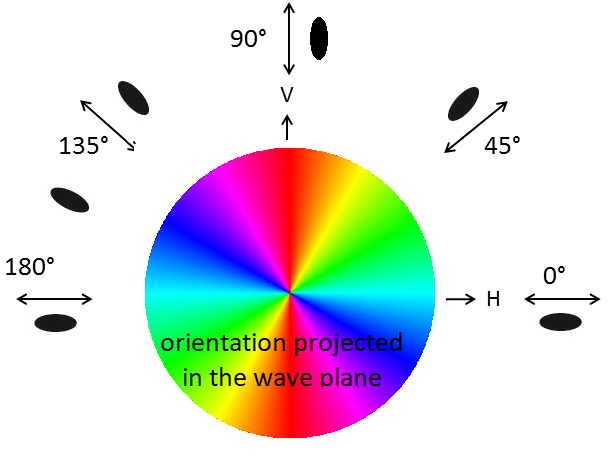

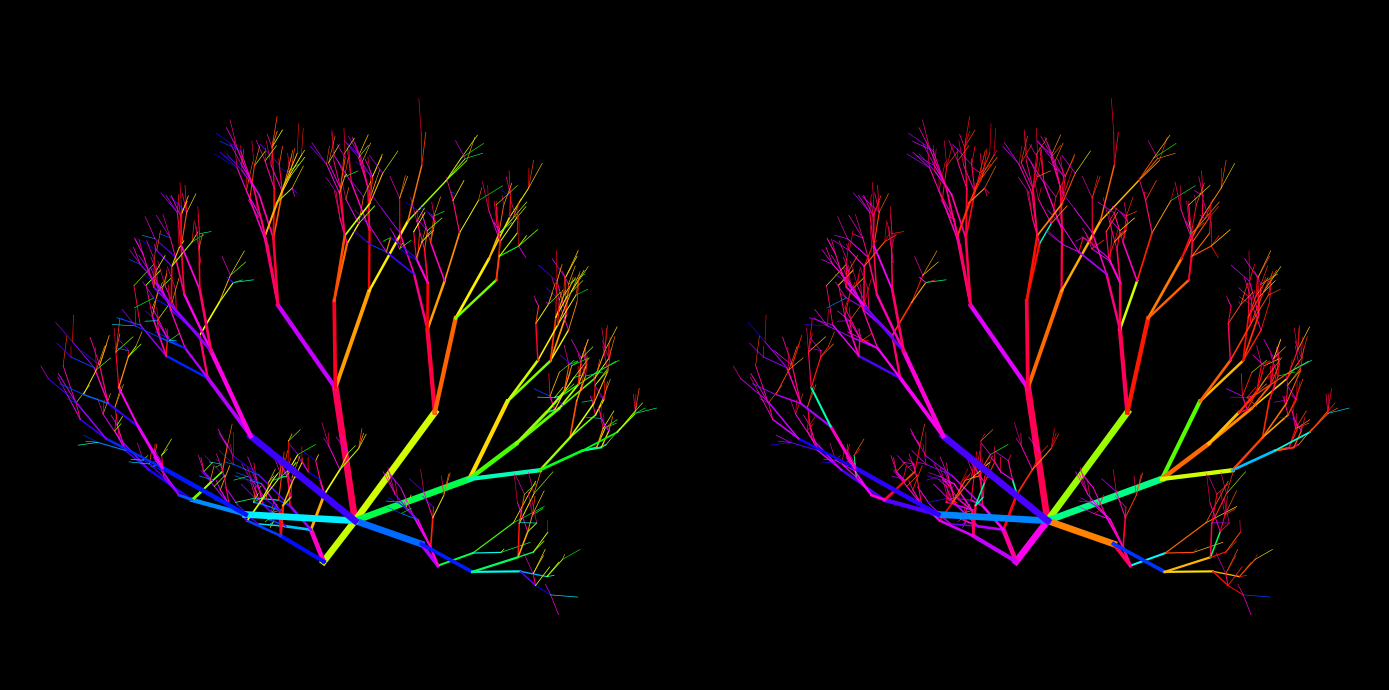

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(14,7))
fig.patch.set_facecolor('black')
# =======================
# GAUCHE : ψ géométrique
# =======================
ax = axs[0]

for start, end, direction, radius in segments:

    # projection plan d’onde
    p1 = np.array([np.dot(start, H), np.dot(start, V)])
    p2 = np.array([np.dot(end, H), np.dot(end, V)])

    # orientation géométrique
    uH = np.dot(direction, H)
    uV = np.dot(direction, V)

    psi_geo = np.arctan2(uV, uH)


    psi_geo_axis =  np.arctan2(
        np.sin(2*psi_geo),
        np.cos(2*psi_geo)
    )
    hue_geo_axis = (psi_geo_axis + np.pi) / (2*np.pi)

    # couleur HSV cohérente
    color = plt.cm.hsv(1-hue_geo_axis)

    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        color=color,
        linewidth=radius * 40
    )
ax.set_facecolor('black')
ax.set_title("ψ_geo (projection)",fontsize=14)
ax.axis('equal')
ax.axis('off')
ax.tick_params(labelsize=16)

# =======================
# DROITE : ψ EM
# =======================
ax = axs[1]

for start, end, direction, radius in segments:

    # projection plan d’onde
    p1 = np.array([np.dot(start, H), np.dot(start, V)])
    p2 = np.array([np.dot(end, H), np.dot(end, V)])

    # diffusion EM
    S = tree_sinclair_coherent(
        [(start, end, direction, radius)],
        freq,
        epsr,
        radar_pos
    )

    # vecteur Pauli
    kp = np.array([S[0,0]+S[1,1],S[0,0]-S[1,1],2*S[0,1]], dtype=complex)
    T = np.outer(kp, np.conj(kp))

    # angle polarimétrique
    psi_em = np.arctan2(np.real(T[0,2]), np.real(T[0,1]))
    hue_em = (psi_em % (2*np.pi)) / (2*np.pi)

    color = plt.cm.hsv(1-hue_em)


    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        color=color,
        linewidth=radius * 40
    )
ax.set_facecolor('black')
ax.set_title("ψ_EM (Sinclair)",fontsize=14)
ax.axis('equal')
ax.axis('off')


plt.tight_layout()
plt.show()

# Variation Frequency, epsilon

In [14]:
def plot_psi(segments, H, V, k, radar_pos, freq, epsr, save_path=None):
    import numpy as np
    import matplotlib.pyplot as plt

    psi_geo_list = []
    psi_em_list = []

    # =======================
    # CALCUL ψ_geo & ψ_EM
    # =======================
    for start, end, direction, radius in segments:

        # --- ψ_geo ---
        uH = np.dot(direction, H)
        uV = np.dot(direction, V)

        psi_geo = np.arctan2(uV, uH)

        psi_geo_axis = np.arctan2(
            np.sin(2 * psi_geo),
            np.cos(2 * psi_geo)
        )
        hue_geo = (psi_geo_axis + np.pi) / (2 * np.pi)

        psi_geo_list.append(hue_geo)

        # --- ψ_EM ---
        S = tree_sinclair_coherent(
            [(start, end, direction, radius)],
            freq,
            epsr,
            radar_pos
        )

        kp = np.array([
            S[0,0] + S[1,1],
            S[0,0] - S[1,1],
            2 * S[0,1]
        ], dtype=complex)

        T = np.outer(kp, np.conj(kp))

        psi_em = np.arctan2(
            np.real(T[0,2]),
            np.real(T[0,1])
        )

        hue_em = (psi_em % (2 * np.pi)) / (2 * np.pi)

        psi_em_list.append(hue_em)

    # =======================
    # FIGURE
    # =======================
    fig, axs = plt.subplots(1, 2, figsize=(14, 7))

    # =======================
    # LEFT : ψ_geo
    # =======================
    ax = axs[0]

    for (start, end, direction, radius), hue_geo in zip(segments, psi_geo_list):

        p1 = np.array([np.dot(start, k), np.dot(start, H)])
        p2 = np.array([np.dot(end, k), np.dot(end, H)])

        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            color=plt.cm.hsv(1 - hue_geo),
            linewidth=radius * 40
        )

    ax.set_facecolor('black')
    ax.set_title(f"ψ_geo (freq={freq/1e9:.1f} GHz)")
    ax.set_xlabel("Range (k)")
    ax.set_ylabel("Azimuth (H)")
    ax.axis('equal')

    # =======================
    # RIGHT : ψ_EM
    # =======================
    ax = axs[1]

    for (start, end, direction, radius), hue_em in zip(segments, psi_em_list):

        p1 = np.array([np.dot(start, k), np.dot(start, H)])
        p2 = np.array([np.dot(end, k), np.dot(end, H)])

        ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            color=plt.cm.hsv(1 - hue_em),
            linewidth=radius * 40
        )

    ax.set_facecolor('black')
    ax.set_title(f"ψ_EM (ε={epsr}, freq={freq/1e9:.1f} GHz)")
    ax.set_xlabel("Range (k)")
    ax.set_ylabel("Azimuth (H)")
    ax.axis('equal')



    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        plt.close(fig)
    else:
        plt.show()


    return fig, axs

In [15]:
import os
import imageio.v2 as imageio
import numpy as np

output_dir = "frames"
os.makedirs(output_dir, exist_ok=True)

freqs = np.linspace(5e9, 10e9, 10)

frames = []

for i, fr in enumerate(freqs):
    print(i,'frequence',fr)
    filename = f"{output_dir}/frame_{i:03d}.png"

    plot_psi(
        segments,
        H, V,
        k,
        radar_pos,
        freq=fr,
        epsr=10 - 1j*2,
        save_path=filename
    )

    frames.append(imageio.imread(filename))

0 frequence 5000000000.0
1 frequence 5555555555.555555
2 frequence 6111111111.111111
3 frequence 6666666666.666667
4 frequence 7222222222.222222
5 frequence 7777777777.777778
6 frequence 8333333333.333334
7 frequence 8888888888.88889
8 frequence 9444444444.444445
9 frequence 10000000000.0


In [16]:
imageio.mimsave("psi_vs_frequency.gif", frames, fps=10,loop=0)

In [17]:
def eps_wood(mv):
    eps_dry = 2.5
    eps_water = 70 - 1j*40

    return eps_dry + mv * (eps_water - eps_dry)

In [20]:
freq = 1.3e9   # bande L typique
mvs = np.linspace(0.0, 0.6, 10)  # de sec à très humide

In [21]:
import os
import imageio.v2 as imageio
import numpy as np

output_dir = "frames"
os.makedirs(output_dir, exist_ok=True)


def eps_wood(mv):
    eps_dry = 2.5
    eps_water = 70 - 1j*40
    return eps_dry + mv * (eps_water - eps_dry)

frames = []

for i, mv in enumerate(mvs):

    epsr = eps_wood(mv)

    print(i, "moisture =", mv, "epsr =", epsr)

    filename = f"{output_dir}/frame_{i:03d}.png"

    plot_psi(
        segments,
        H, V,
        k,
        radar_pos,
        freq=freq,
        epsr=epsr,
        save_path=filename
    )

    frames.append(imageio.imread(filename))

0 moisture = 0.0 epsr = (2.5+0j)
1 moisture = 0.06666666666666667 epsr = (7-2.6666666666666665j)
2 moisture = 0.13333333333333333 epsr = (11.5-5.333333333333333j)
3 moisture = 0.2 epsr = (16-8j)
4 moisture = 0.26666666666666666 epsr = (20.5-10.666666666666666j)
5 moisture = 0.3333333333333333 epsr = (25-13.333333333333332j)
6 moisture = 0.4 epsr = (29.5-16j)
7 moisture = 0.4666666666666667 epsr = (34-18.666666666666668j)
8 moisture = 0.5333333333333333 epsr = (38.5-21.333333333333332j)
9 moisture = 0.6 epsr = (43-24j)


In [22]:
imageio.mimsave("psi_vs_water.gif", frames, fps=10,loop=0)

# Analysis of one single Cylinder

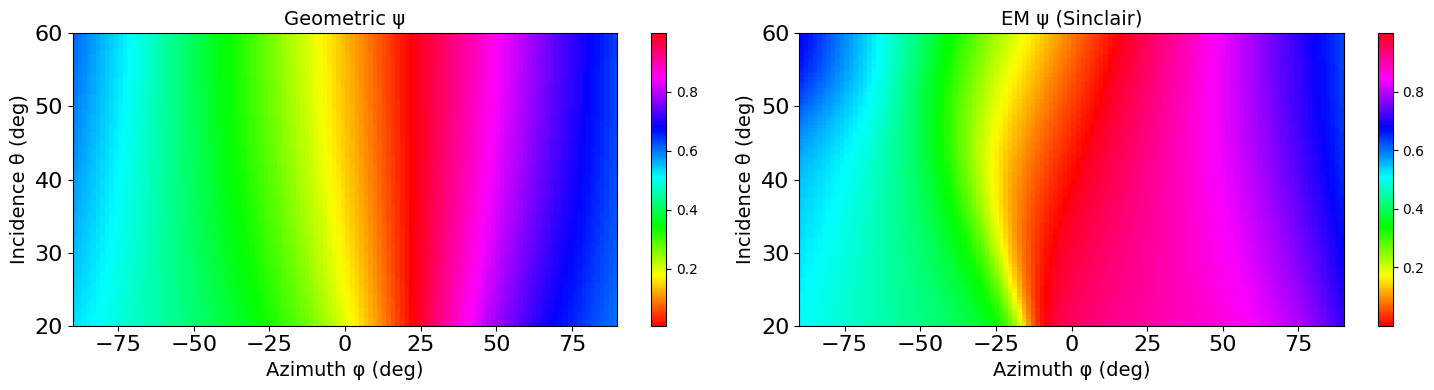

In [25]:
freq=5e9
epsr=3-5j

# =======================
# Cylinder parameters
# =======================

# Unit direction vector of the cylinder
axis_vec = np.array([0.7, 0.3, 0.1])
axis_vec = axis_vec / np.linalg.norm(axis_vec)

# Geometric properties
cyl_radius = 0.01
cyl_length = 0.5

# Endpoints of the segment
p_start = np.array([0, 0, 0])
p_end = axis_vec * cyl_length

# Single cylinder definition
cyl_segment = (p_start, p_end, axis_vec, cyl_radius)

# =======================
# Radar angular grid
# =======================

theta_grid = np.deg2rad(np.linspace(20, 60, 80))   # incidence angles
phi_grid = np.deg2rad(np.linspace(-90, 90, 120))   # azimuth angles

# Output maps
psi_geo_map = np.zeros((len(theta_grid), len(phi_grid)))
psi_em_map = np.zeros_like(psi_geo_map)

# =======================
# Main loop over radar geometry
# =======================

for i, theta_loop in enumerate(theta_grid):
    for j, phi_loop in enumerate(phi_grid):

        # --- Local radar line-of-sight vector ---
        k_loop = np.array([
            np.sin(theta_loop) * np.cos(phi_loop),
            np.sin(theta_loop) * np.sin(phi_loop),
            -np.cos(theta_loop)
        ])
        k_loop /= np.linalg.norm(k_loop)

        # --- Local polarimetric basis ---
        H_loop, V_loop = radar_basis(k_loop)

        # ----------------------------
        # Geometric polarimetric angle
        # ----------------------------

        # Projection of cylinder axis onto (H, V)
        proj_H_loop = np.dot(axis_vec, H_loop)
        proj_V_loop = np.dot(axis_vec, V_loop)

        psi_geo = np.arctan2(proj_V_loop, proj_H_loop)

        psi_geo_axis = np.arctan2(
            np.sin(2 * psi_geo),
            np.cos(2 * psi_geo)
        )

        hue_geo_loop = (psi_geo_axis + np.pi) / (2 * np.pi)

        # ----------------------------
        # Electromagnetic polarimetric angle
        # ----------------------------

        # Local radar position
        radar_pos_loop = -R * k_loop

        S_loop = tree_sinclair_coherent(
            [cyl_segment],
            freq,
            epsr,
            radar_pos_loop
        )

        # Pauli vector
        pauli_vec_loop = np.array([
            S_loop[0, 0] + S_loop[1, 1],
            S_loop[0, 0] - S_loop[1, 1],
            2 * S_loop[0, 1]
        ], dtype=complex)

        # Coherency matrix
        coherency_loop = np.outer(pauli_vec_loop, np.conj(pauli_vec_loop))

        # EM polarimetric angle
        psi_em = np.arctan2(
            np.real(coherency_loop[0, 2]),
            np.real(coherency_loop[0, 1])
        )

        hue_em_loop = (psi_em % (2 * np.pi)) / (2 * np.pi)

        # Store results
        psi_geo_map[i, j] = 1-hue_geo_loop
        psi_em_map[i, j] = 1-hue_em_loop

# =======================
# Difference map
# =======================

delta_map = psi_em_map - psi_geo_map

# =======================
# Visualization
# =======================

extent = [
    np.rad2deg(phi_grid[0]),
    np.rad2deg(phi_grid[-1]),
    np.rad2deg(theta_grid[0]),
    np.rad2deg(theta_grid[-1])
]

plt.figure(figsize=(15, 4))

# --- Geometric angle ---
plt.subplot(1, 2, 1)
plt.imshow(psi_geo_map, extent=extent, aspect='auto', cmap='hsv')
plt.title("Geometric ψ", fontsize=14)
plt.xlabel("Azimuth φ (deg)", fontsize=14)
plt.ylabel("Incidence θ (deg)", fontsize=14)
plt.colorbar()
plt.tick_params(labelsize=16)

# --- Electromagnetic angle ---
plt.subplot(1, 2, 2)
plt.imshow(psi_em_map, extent=extent, aspect='auto', cmap='hsv')
plt.title("EM ψ (Sinclair)", fontsize=14)
plt.xlabel("Azimuth φ (deg)", fontsize=14)
plt.ylabel("Incidence θ (deg)", fontsize=14)
plt.colorbar()
plt.tick_params(labelsize=16)

plt.tight_layout()
plt.show()